In [1]:
import os
import skrf as rf
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import matplotlib.patches as mpatches

In [2]:
def smooth_network(network, window=11, poly=3):
    """
    Smooth all S-parameters of a Network using Savitzky–Golay filter.
    Returns a new smoothed Network.
    """
    s = network.s.copy()
    n_freq, n_port, _ = s.shape

    s_smooth = np.zeros_like(s, dtype=complex)

    for i in range(n_port):
        for j in range(n_port):
            real_part = np.real(s[:, i, j])
            imag_part = np.imag(s[:, i, j])

            real_smooth = savgol_filter(real_part, window, poly)
            imag_smooth = savgol_filter(imag_part, window, poly)

            s_smooth[:, i, j] = real_smooth + 1j * imag_smooth

    smoothed_network = rf.Network(
        frequency=network.frequency,
        s=s_smooth,
        z0=network.z0
    )

    return smoothed_network


def load_directory(directory_path, window=30, poly=3):
    """
    Reads all .s2p files in a directory.
    Can Return two lists:
        {directory_name}_original
        {directory_name}_smoothed
    """

    directory_name = os.path.basename(os.path.normpath(directory_path))

    original_list = []
    smoothed_list = []

    for file in sorted(os.listdir(directory_path)):
        if file.lower().endswith(".s2p"):

            full_path = os.path.join(directory_path, file)

            # Load original network
            ntwk = rf.Network(full_path)

            # Use filename (without extension) as network name
            name = os.path.splitext(file)[0]
            ntwk.name = name

            original_list.append(ntwk)

            # Create smoothed version
            ntwk_smooth = smooth_network(ntwk, window, poly)
            ntwk_smooth.name = name

            smoothed_list.append(ntwk_smooth)

    # Dynamically create variable names
    globals()[f"{directory_name}_measured"] = original_list
    globals()[f"{directory_name}_smoothed"] = smoothed_list

    return original_list, smoothed_list


def avg_return_loss(ntwk):
    s11_db = ntwk.s_db[:,0,0]
    return np.mean(s11_db)
def worst_return_loss(ntwk):
    return np.max(ntwk.s_db[:640,0,0])   # closest to 0 dB
def avg_transmit_loss(ntwk):
    s11_db = ntwk.s_db[:,1,0]
    return np.mean(s11_db)
def worst_transmit_loss(ntwk):
    return np.max(ntwk.s_db[:,1,0])   # closest to 0 dB

In [3]:
from pathlib import Path
path1 = Path('GEECI_meas_18min_21_may_2026')

geeci_files = []
directory = path1
for file in directory.iterdir():
    geeci_files.append(file)
geeci_files

[WindowsPath('GEECI_meas_18min_21_may_2026/cal_data.s2p'),
 WindowsPath('GEECI_meas_18min_21_may_2026/cal_state.csa'),
 WindowsPath('GEECI_meas_18min_21_may_2026/DMD'),
 WindowsPath('GEECI_meas_18min_21_may_2026/S21_param.txt'),
 WindowsPath('GEECI_meas_18min_21_may_2026/S21_param_.txt'),
 WindowsPath('GEECI_meas_18min_21_may_2026/SUB1'),
 WindowsPath('GEECI_meas_18min_21_may_2026/SUB2'),
 WindowsPath('GEECI_meas_18min_21_may_2026/SUB3'),
 WindowsPath('GEECI_meas_18min_21_may_2026/S_param.txt'),
 WindowsPath('GEECI_meas_18min_21_may_2026/S_param_.txt')]

In [4]:
# refrencing files with the same names across different samples:
from pathlib import Path

# Define the parent directory
parent_dir = path1

# list to contain paths of all files found
thru_files_nos1 = []
thru_files_nos2 = []
thru_files_nos3 = []
thru_files17um_all = []
thru_covered17um_all = []

FCB_tr_overlap17um_30um = []
FCB_pillar_pitch17um_100um = []
FCB_tr_overlap17um_120um = []
# Search for files containing specific characters (e.g., "target")
# The '**' searches all subfolders recursively



matching_files = list(parent_dir.glob("**/*thru*.*"))
for file_path in matching_files:
    # print(f"Found file: {file_path.name} in {file_path.parent}")
    thru_files17um_all.append(file_path)

matching_files3 = list((Path('GEECI_meas_18min_21_may_2026') / 'DMD').glob("**/*floating*.*"))
for file_path in matching_files3:
    print(f"Found file: {file_path.name} in {file_path.parent}")
    thru_covered17um_all.append(file_path)

matching_files4 = list(parent_dir.glob("**/*15um*.*"))
for file_path in matching_files4:
    # print(f"Found file: {file_path.name} in {file_path.parent}")
    FCB_tr_overlap17um_30um.append(file_path)

matching_files5 = list(parent_dir.glob("**/*_60um*.*"))
for file_path in matching_files5:
    # print(f"Found file: {file_path.name} in {file_path.parent}")
    FCB_tr_overlap17um_120um.append(file_path)




Found file: floating_die_tn4.s2p in GEECI_meas_18min_21_may_2026\DMD\SETB_excluded_meas
Found file: floating_die_tn5.s2p in GEECI_meas_18min_21_may_2026\DMD\SETB_excluded_meas
Found file: floating_die_tn6.s2p in GEECI_meas_18min_21_may_2026\DMD\SETB_excluded_meas


In [5]:
pillar_locs, pillar_loc_smooth = load_directory(r'GEECI_meas_18min_21_may_2026\SUB3\SETA',window=30, poly=3)


In [6]:
pillar_loc_smooth[3:]

[2-Port Network: 'tn1_60.5',  1000000000.0-45000000000.0 Hz, 1601 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'tn2_100.5',  1000000000.0-45000000000.0 Hz, 1601 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'tn3_196.5',  1000000000.0-45000000000.0 Hz, 1601 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'tn4_60,5',  1000000000.0-45000000000.0 Hz, 1601 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'tn5_100.5',  1000000000.0-45000000000.0 Hz, 1601 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: 'tn6_196.5',  1000000000.0-45000000000.0 Hz, 1601 pts, z0=[50.+0.j 50.+0.j]]

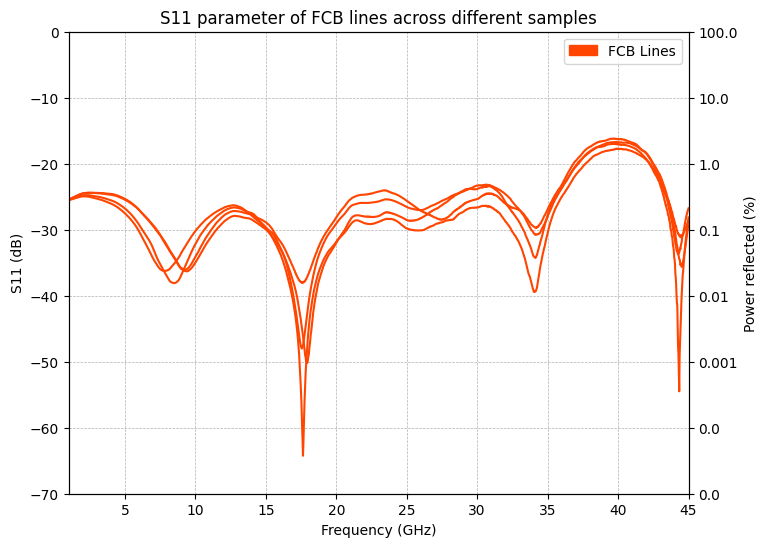

In [11]:
from matplotlib import ticker
from scipy.signal import find_peaks
dip1_freqs = []
dip2_freqs = []
dip3_freqs = []
dip4_freqs = []
# plotting the S11 of through lines nos1
plt.figure(figsize=(8,6))
plt.title("S11 parameter of FCB lines across different samples")

#changinf axis ticks
from matplotlib.ticker import MultipleLocator
ax1 = plt.gca()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# for path in thru_files17um_all[:4]:
#     path_obj = Path(path)
#     # folder_label = "/".join(path_obj.parts[-3:])  # Get the last two directories
#     ntwk = rf.Network(path)
#     ntwk = smooth_network(ntwk, window=30, poly=3)
#     s11 = ntwk.s_db[:,0,0]
#     ntwk.frequency.unit = 'GHz'
#     ntwk.plot_s_db(m=0,n=0, color='royalblue')
# royalblue_patch = mpatches.Patch(color='royalblue', label='Through Lines')


for path in FCB_tr_overlap17um_30um:
    path_obj = Path(path)
    # folder_label = "/".join(path_obj.parts[-3:])  # Get the last two directories

    ntwk = rf.Network(path)
    ntwk = smooth_network(ntwk, window=30, poly=3)
    # s11 = ntwk.s_db[:,0,0]
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=0,n=0, color='orangered')
orangered_patch = mpatches.Patch(color='orangered', label='FCB Lines')
plt.legend(handles=[ orangered_patch])
# --- SET Y-AXIS LIMITS HERE ---
ax1.set_ylim(-70, 0)
ax1.set_ylabel("S11 (dB)")


# --- SECONDARY AXIS CODE ---
ax2 = ax1.twinx()

# Sync limits with ax1
ax2.set_ylim(ax1.get_ylim())

# Sync ticks with ax1 and convert labels to percentage
y_ticks_db = ax1.get_yticks()
y_ticks_pct = [round(10**(tick/10) * 100, 3) for tick in y_ticks_db]

ax2.set_yticks(y_ticks_db)
ax2.set_yticklabels(y_ticks_pct)
ax2.set_ylabel('Power reflected (%)')

# Save and show
plt.savefig('S11 parameter of FCB lines across different samples.png', dpi=300, bbox_inches='tight')
plt.show()


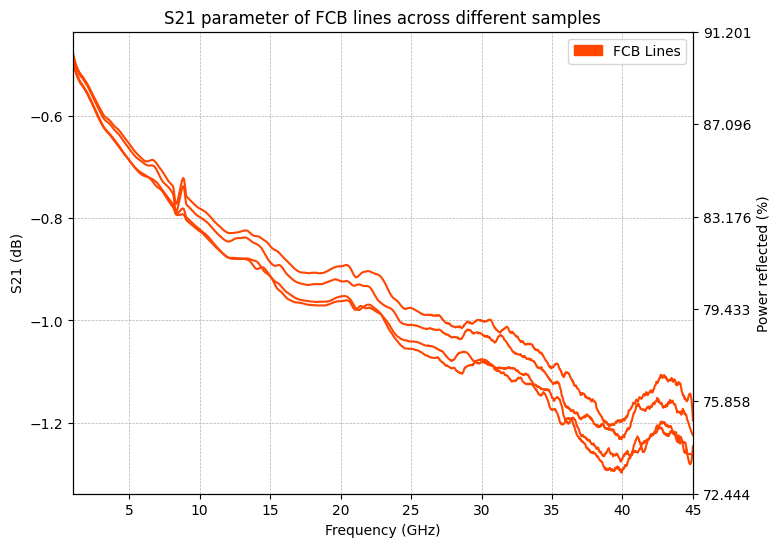

In [12]:
from matplotlib import ticker
from scipy.signal import find_peaks
dip1_freqs = []
dip2_freqs = []
dip3_freqs = []
dip4_freqs = []
# plotting the S21 of through lines nos1
plt.figure(figsize=(8,6))
plt.title("S21 parameter of FCB lines across different samples")

#changinf axis ticks
from matplotlib.ticker import MultipleLocator
ax1 = plt.gca()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# for path in thru_files17um_all[:4]:
#     path_obj = Path(path)
#     # folder_label = "/".join(path_obj.parts[-3:])  # Get the last two directories
#     ntwk = rf.Network(path)
#     ntwk = smooth_network(ntwk, window=30, poly=3)
#     # s21 = ntwk.s_db[:,1,0]
#     ntwk.frequency.unit = 'GHz'
#     ntwk.plot_s_db(m=1,n=0, color='royalblue')
# royalblue_patch = mpatches.Patch(color='royalblue', label='Through Lines')


for path in FCB_tr_overlap17um_30um:
    path_obj = Path(path)
    # folder_label = "/".join(path_obj.parts[-3:])  # Get the last two directories

    ntwk = rf.Network(path)
    ntwk = smooth_network(ntwk, window=30, poly=3)
    # s21 = ntwk.s_db[:,1,0]
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=1,n=0, color='orangered')
orangered_patch = mpatches.Patch(color='orangered', label='FCB Lines')
plt.legend(handles=[ orangered_patch])
# --- SET Y-AXIS LIMITS HERE ---
# ax1.set_ylim(-70, 0)
ax1.set_ylabel("S21 (dB)")

# --- SECONDARY AXIS CODE ---
ax2 = ax1.twinx()

# Sync limits with ax1
ax2.set_ylim(ax1.get_ylim())

# Sync ticks with ax1 and convert labels to percentage
y_ticks_db = ax1.get_yticks()
y_ticks_pct = [round(10**(tick/10) * 100, 3) for tick in y_ticks_db]

ax2.set_yticks(y_ticks_db)
ax2.set_yticklabels(y_ticks_pct)
ax2.set_ylabel('Power reflected (%)')

# Save and show
plt.savefig('S21 parameter of FCB lines across different samples.png', dpi=300, bbox_inches='tight')
plt.show()


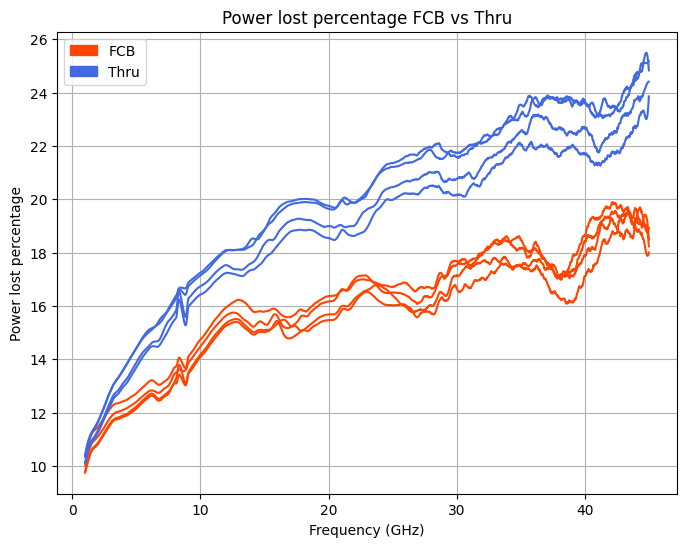

In [ ]:
plt.figure(figsize=(8, 6))

for path in thru_files17um_all[:4]:  # Example: plot first 5 networks
    path_obj = Path(path)
    ntwk = rf.Network(path)
    ntwk = smooth_network(ntwk, window=30, poly=3)
    ntwk.frequency.unit = 'GHz'
    s11 = ntwk.s_mag[:, 0, 0]  # Extract S11
    s21 = ntwk.s_mag[:, 1, 0]  # Extract S21
    lost_power_fraction = [100 * (1-(x*x +y*y)) for x, y in zip(s11, s21)]
    plt.plot(ntwk.frequency.f/1e9, lost_power_fraction, color='orangered')
royalblue_patch = mpatches.Patch(color='orangered', label='FCB')
    
for path in FCB_tr_overlap17um_30um:  # Example: plot first 5 networks
    path_obj = Path(path)
    ntwk = rf.Network(path)
    ntwk = smooth_network(ntwk, window=30, poly=3)
    ntwk.frequency.unit = 'GHz'
    s11 = ntwk.s_mag[:, 0, 0]  # Extract S11
    s21 = ntwk.s_mag[:, 1, 0]  # Extract S21
    lost_power_fraction = [100 * (1-(x*x +y*y)) for x, y in zip(s11, s21)]
    plt.plot(ntwk.frequency.f/1e9, lost_power_fraction, color='royalblue')
orangered_patch = mpatches.Patch(color='royalblue', label='Thru')

plt.xlabel("Frequency (GHz)")
plt.ylabel("Power lost percentage")
plt.title("Power lost percentage FCB vs Thru")
plt.grid(True)
plt.legend(handles=[royalblue_patch, orangered_patch])
plt.savefig('power_lost_percent_Detuning_effect_comparison.png', dpi=300)

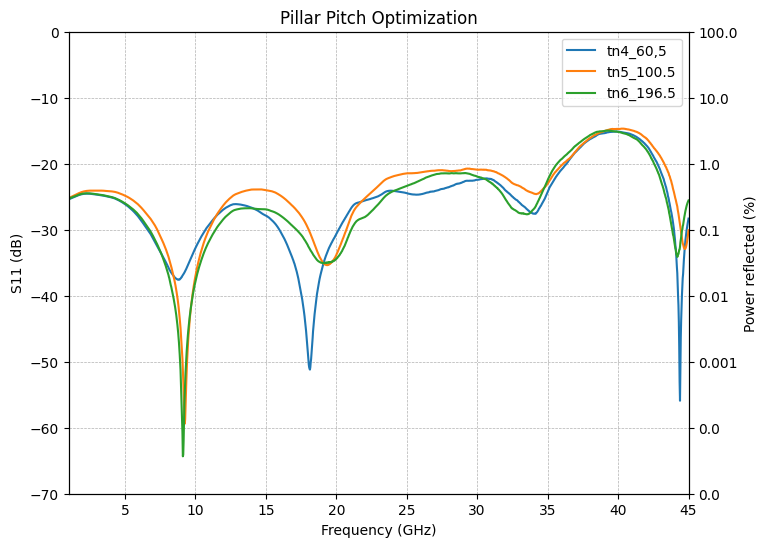

In [ ]:
from matplotlib import ticker
from scipy.signal import find_peaks

# plotting the S11 of through lines nos1
plt.figure(figsize=(8,6))
plt.title("Pillar Pitch Optimization")

#changinf axis ticks
from matplotlib.ticker import MultipleLocator
ax1 = plt.gca()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

for ntwk in pillar_loc_smooth[6:]:
    # folder_label = "/".join(path_obj.parts[-3:-1])  # Get the last two directories
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=0,n=0, label = f'{ntwk.name}')

ax1.set_ylim(-70, 0)
ax1.set_ylabel("S11 (dB)")


# --- SECONDARY AXIS CODE ---
ax2 = ax1.twinx()

# Sync limits with ax1
ax2.set_ylim(ax1.get_ylim())

# Sync ticks with ax1 and convert labels to percentage
y_ticks_db = ax1.get_yticks()
y_ticks_pct = [round(10**(tick/10) * 100, 3) for tick in y_ticks_db]

ax2.set_yticks(y_ticks_db)
ax2.set_yticklabels(y_ticks_pct)
ax2.set_ylabel('Power reflected (%)')

# Save and show
plt.savefig('Pillar location otpimization.png', dpi=300, bbox_inches='tight')
plt.show()


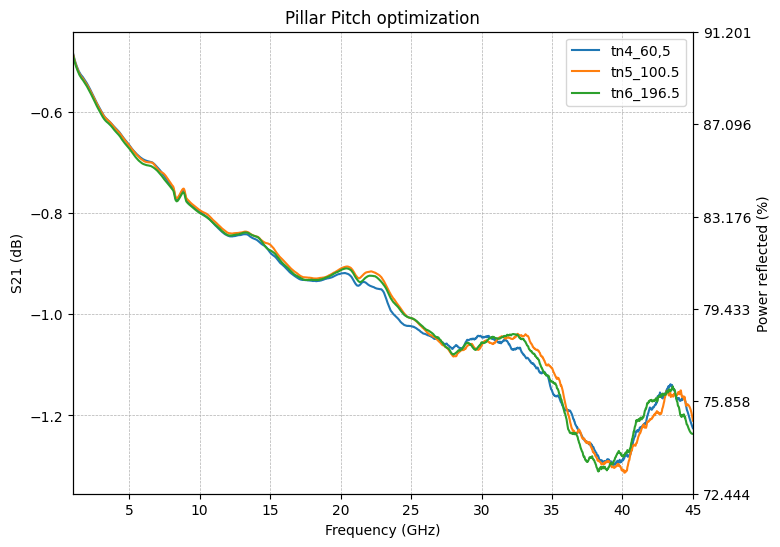

In [ ]:
from matplotlib import ticker
from scipy.signal import find_peaks

# plotting the S11 of through lines nos1
plt.figure(figsize=(8,6))
plt.title("Pillar Pitch optimization")

#changinf axis ticks
from matplotlib.ticker import MultipleLocator
ax1 = plt.gca()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

for ntwk in pillar_loc_smooth[6:]:
    # folder_label = "/".join(path_obj.parts[-3:-1])  # Get the last two directories
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=1,n=0, label = f'{ntwk.name}')

# ax1.set_ylim(-70, 0)
ax1.set_ylabel("S21 (dB)")


# --- SECONDARY AXIS CODE ---
ax2 = ax1.twinx()

# Sync limits with ax1
ax2.set_ylim(ax1.get_ylim())

# Sync ticks with ax1 and convert labels to percentage
y_ticks_db = ax1.get_yticks()
y_ticks_pct = [round(10**(tick/10) * 100, 3) for tick in y_ticks_db]

ax2.set_yticks(y_ticks_db)
ax2.set_yticklabels(y_ticks_pct)
ax2.set_ylabel('Power reflected (%)')

# Save and show
plt.savefig('Pillar location otpimization.png', dpi=300, bbox_inches='tight')
plt.show()


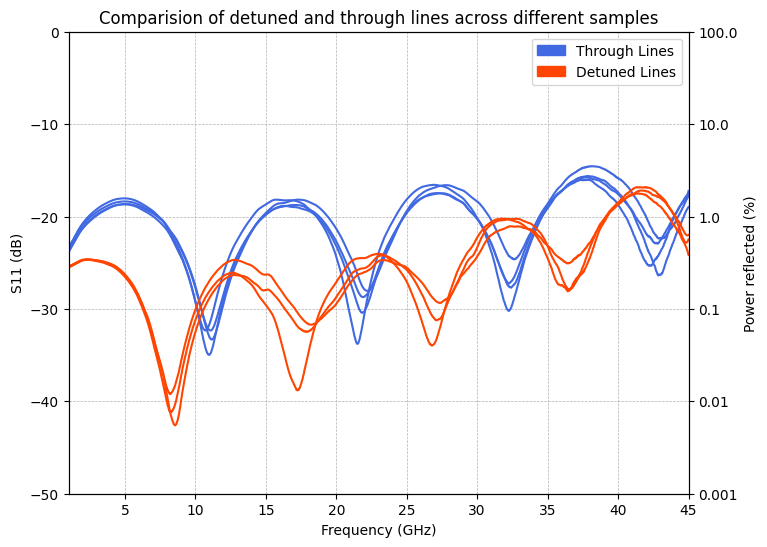

In [ ]:
from matplotlib import ticker
from scipy.signal import find_peaks
dip1_freqs = []
dip2_freqs = []
dip3_freqs = []
dip4_freqs = []
# plotting the S11 of through lines nos1
plt.figure(figsize=(8,6))
plt.title("Comparision of detuned and through lines across different samples")

#changinf axis ticks
from matplotlib.ticker import MultipleLocator
ax1 = plt.gca()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

for path in thru_files17um_all[:4]:
    path_obj = Path(path)
    # folder_label = "/".join(path_obj.parts[-3:])  # Get the last two directories
    ntwk = rf.Network(path)
    ntwk = smooth_network(ntwk, window=30, poly=3)
    s11 = ntwk.s_db[:,0,0]
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=0,n=0, color='royalblue')
royalblue_patch = mpatches.Patch(color='royalblue', label='Through Lines')


for path in thru_covered17um_all:
    path_obj = Path(path)
    # folder_label = "/".join(path_obj.parts[-3:])  # Get the last two directories

    ntwk = rf.Network(path)
    ntwk = smooth_network(ntwk, window=30, poly=3)
    # s11 = ntwk.s_db[:,0,0]
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=0,n=0, color='orangered')
orangered_patch = mpatches.Patch(color='orangered', label='Detuned Lines')
plt.legend(handles=[royalblue_patch, orangered_patch])
# --- SET Y-AXIS LIMITS HERE ---
ax1.set_ylim(-50, 0)
ax1.set_ylabel("S11 (dB)")


# --- SECONDARY AXIS CODE ---
ax2 = ax1.twinx()

# Sync limits with ax1
ax2.set_ylim(ax1.get_ylim())

# Sync ticks with ax1 and convert labels to percentage
y_ticks_db = ax1.get_yticks()
y_ticks_pct = [round(10**(tick/10) * 100, 3) for tick in y_ticks_db]

ax2.set_yticks(y_ticks_db)
ax2.set_yticklabels(y_ticks_pct)
ax2.set_ylabel('Power reflected (%)')

# Save and show
plt.savefig('Comparision of FCB and through lines across different samples.png', dpi=300, bbox_inches='tight')
plt.show()


# ABCD matrix

In [ ]:
import numpy as np

def scale_transmission_line_curve_fit(T_array, orig_length, desired_length):
    """
    Scales a T-matrix array by parametrically fitting the underlying physical 
    constants (Z0 and gamma), rendering it 100% immune to VNA resonance noise.
    """
    # Create a linear index array for stable polynomial fitting
    N = len(T_array)
    x = np.arange(N)

    A = T_array[:, 0, 0]
    B = T_array[:, 0, 1]
    C = T_array[:, 1, 0]
    
    # ---------------------------------------------------------
    # 1. RAW EXTRACTIONS
    # ---------------------------------------------------------
    Z0_raw = np.sqrt(B / C)
    
    root_term = np.sqrt(A**2 - 1.0 + 0j) 
    root1 = A + root_term
    root2 = A - root_term
    exp_minus_gl = np.where(np.abs(root1) < 1.0, root1, root2)
    
    alpha_l_raw = -np.log(np.abs(exp_minus_gl)) 
    unwrapped_phase_raw = np.unwrap(np.angle(exp_minus_gl))
    
    # ---------------------------------------------------------
    # 2. ADAPTIVE NOISE MASKING
    # ---------------------------------------------------------
    # Automatically find the true baseline impedance using the median.
    # This prevents the mask from failing if your line is 55 ohms instead of 50.
    Z0_mag = np.abs(Z0_raw)
    median_Z0 = np.median(Z0_mag)
    
    # Keep only the pristine data within +/- 20% of the median baseline.
    # This aggressively rejects both the spikes AND the noisy "shoulders".
    valid_mask = (Z0_mag > median_Z0 * 0.8) & (Z0_mag < median_Z0 * 1.2)
    x_valid = x[valid_mask]
    
    # ---------------------------------------------------------
    # 3. PARAMETRIC CURVE FITTING (The Ultimate Smoother)
    # ---------------------------------------------------------
    # Fit a 3rd-order polynomial to the clean data to capture natural dispersion
    p_Z0_real = np.polyfit(x_valid, np.real(Z0_raw)[valid_mask], 3)
    p_Z0_imag = np.polyfit(x_valid, np.imag(Z0_raw)[valid_mask], 3)
    
    p_alpha = np.polyfit(x_valid, alpha_l_raw[valid_mask], 3)
    p_phase = np.polyfit(x_valid, unwrapped_phase_raw[valid_mask], 3)
    
    # Reconstruct perfectly smooth, continuous parameters over the entire sweep
    Z0_clean = np.polyval(p_Z0_real, x) + 1j * np.polyval(p_Z0_imag, x)
    gamma_l_clean = np.polyval(p_alpha, x) - 1j * np.polyval(p_phase, x)
    
    # ---------------------------------------------------------
    # 4. REBUILD THE SCALED MATRIX
    # ---------------------------------------------------------
    scaling_factor = desired_length / orig_length
    gamma_l_new = gamma_l_clean * scaling_factor
    
    T_new = np.zeros_like(T_array, dtype=complex)
    
    T_new[:, 0, 0] = np.cosh(gamma_l_new)
    T_new[:, 0, 1] = Z0_clean * np.sinh(gamma_l_new)
    T_new[:, 1, 0] = np.sinh(gamma_l_new) / Z0_clean
    T_new[:, 1, 1] = T_new[:, 0, 0]
    
    return T_new

import numpy as np

def deembed_arrays(T_total, T_left, T_right):
    """
    De-embeds left and right transmission lines from a total cascaded T-matrix.
    
    Parameters:
    T_total : ndarray of shape (N, 2, 2)
    T_left  : ndarray of shape (N, 2, 2) representing the left feedline
    T_right : ndarray of shape (N, 2, 2) representing the right feedline
    
    Returns:
    T_dut   : ndarray of shape (N, 2, 2) representing the de-embedded device
    """
    
    # 1. Invert the left and right feedline arrays
    # np.linalg.inv automatically handles stacks of matrices (N, 2, 2)
    T_left_inv = np.linalg.inv(T_left)
    T_right_inv = np.linalg.inv(T_right)
    
    # 2. Perform the cascaded multiplication
    # The '@' operator (which calls np.matmul) automatically broadcasts 
    # over the N frequency points, multiplying each 2x2 matrix pair.
    T_dut = T_left_inv @ T_total @ T_right_inv
    
    return T_dut

# --- Example Usage ---
# N = 1001 frequency points
# T_total = np.random.rand(1001, 2, 2) + 1j * np.random.rand(1001, 2, 2)
# T_left = ...
# T_right = ...
# 
# T_dut = deembed_arrays(T_total, T_left, T_right)

def plot_abcd(abcd_matrices,x,y):
    plt.plot(freq_GHz, np.real(abcd_matrices[:,x,y]), label=f'read {x},{y}', color='blue', linewidth=2)
    plt.plot(freq_GHz, np.imag(abcd_matrices[:,x,y]), label=f'Imag({x},{y})', color='red', linewidth=2)
    plt.title(' Parameter vs Frequency')
    plt.xlabel('Frequency (GHz)')
    plt.ylabel('Impedance (Ohms)')
    plt.legend()
    plt.grid(True, which='both', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

def extract_and_plot_transition_RLC(T_inner, T_thru, freq_hz):
    """
    Extracts the lumped R, L, C values of a symmetric transition from a 
    cascaded T_inner matrix (T_trans * T_thru * T_trans) using optimization,
    and plots the results across frequency.
    """
    N = len(freq_hz)
    R_ext = np.zeros(N)
    L_ext = np.zeros(N)
    C_ext = np.zeros(N)
    
    print(f"Optimizing RLC values across {N} frequency points...")

    # Loop over each frequency point
    for i in range(N):
        w = 2.0 * np.pi * freq_hz[i] + 1e-15 # Add offset to prevent div by zero at DC
        T_in = T_inner[i]
        T_th = T_thru[i]

        # ---------------------------------------------------------
        # THE OBJECTIVE FUNCTION
        # ---------------------------------------------------------
        def error_func(params):
            # params = [R, L_in_pH, C_in_fF]
            R, L_pH, C_fF = params 
            
            L = L_pH * 1e-12
            C = C_fF * 1e-15
            
            Z = R + 1j * w * L
            Y = 1j * w * C
            
            # Build the theoretical Pi-network T_trans matrix
            A_t = 1.0 + Z * Y
            B_t = Z
            C_t = 2.0 * Y + Z * (Y**2)
            D_t = A_t
            T_trans = np.array([[A_t, B_t], 
                                [C_t, D_t]], dtype=complex)
            
            # Cascade the math: T_trans * T_thru * T_trans
            T_calc = T_trans @ T_th @ T_trans
            
            # Return the sum of squared errors between calculation and measurement
            return np.sum(np.abs(T_calc - T_in)**2)

        # ---------------------------------------------------------
        # INITIAL GUESS & OPTIMIZATION
        # ---------------------------------------------------------
        # Use the previous point's result as the next guess to ensure 
        # a perfectly continuous curve across the frequency sweep.
        if i == 0:
            guess = [0.5, 10.0, 15.0]  # Start with 0.5 ohm, 10 pH, 15 fF
        else:
            guess = [R_ext[i-1], L_ext[i-1]*1e12, C_ext[i-1]*1e15]

        # Run the optimizer. Bounds ensure R, L, and C cannot be physically negative.
        # Format: bounds=((R_min, R_max), (L_min, L_max), (C_min, C_max))
        res = minimize(error_func, guess, bounds=((0, 50), (0, 300), (0, 300)))

        # Store the successful extractions
        R_ext[i] = res.x[0]
        L_ext[i] = res.x[1] * 1e-12
        C_ext[i] = res.x[2] * 1e-15

    # ---------------------------------------------------------
    # PLOTTING THE RESULTS
    # ---------------------------------------------------------
    freq_GHz = freq_hz / 1e9
    
    fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
    
    # Resistance Plot
    axs[0].plot(freq_GHz, R_ext, 'r', linewidth=2)
    axs[0].set_ylabel('Resistance (Ohms)')
    axs[0].set_title('Extracted Transition Parameters vs Frequency')
    axs[0].grid(True, linestyle='--', alpha=0.7)
    
    # Inductance Plot
    axs[1].plot(freq_GHz, L_ext * 1e12, 'b', linewidth=2)
    axs[1].set_ylabel('Inductance (pH)')
    axs[1].grid(True, linestyle='--', alpha=0.7)
    
    # Capacitance Plot
    axs[2].plot(freq_GHz, C_ext * 1e15, 'g', linewidth=2)
    axs[2].set_ylabel('Capacitance (fF)')
    axs[2].set_xlabel('Frequency (GHz)')
    axs[2].grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

    return R_ext, L_ext, C_ext

import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

def extract_and_plot_transition_RLC_robust(T_inner, T_thru, freq_hz):
    N = len(freq_hz)
    R_ext = np.zeros(N)
    L_ext = np.zeros(N)
    C_ext = np.zeros(N)
    
    print(f"Optimizing RLC values across {N} frequency points...")

    for i in range(N):
        w = 2.0 * np.pi * freq_hz[i] + 1e-15 
        T_in = T_inner[i]
        T_th = T_thru[i]

        # ---------------------------------------------------------
        # THE NORMALIZED OBJECTIVE FUNCTION
        # ---------------------------------------------------------
        def error_func(params):
            R, L_pH, C_fF = params 
            
            L = L_pH * 1e-12
            C = C_fF * 1e-15
            
            Z = R + 1j * w * L
            Y = 1j * w * C
            
            A_t = 1.0 + Z * Y
            B_t = Z
            C_t = 2.0 * Y + Z * (Y**2)
            D_t = A_t
            
            T_trans = np.array([[A_t, B_t], 
                                [C_t, D_t]], dtype=complex)
            
            T_calc = T_trans @ T_th @ T_trans
            
            # Normalize the parameters to a 50-ohm system so the optimizer 
            # weights R, L, and C equally.
            err_A = np.abs(T_calc[0, 0] - T_in[0, 0])**2
            err_B = np.abs((T_calc[0, 1] - T_in[0, 1]) / 50.0)**2
            err_C = np.abs((T_calc[1, 0] - T_in[1, 0]) * 50.0)**2
            err_D = np.abs(T_calc[1, 1] - T_in[1, 1])**2
            
            return err_A + err_B + err_C + err_D

        # ---------------------------------------------------------
        # THE "RESCUE" GUESS PROTOCOL
        # ---------------------------------------------------------
        # If it's the first point, OR if the previous point crashed to near-zero,
        # reset to a safe, physical starting guess.
        if i == 0 or R_ext[i-1] < 1e-2 or L_ext[i-1]*1e12 < 1e-2 or C_ext[i-1]*1e15 < 1e-2:
            guess = [0.5, 10.0, 15.0] 
        else:
            guess = [R_ext[i-1], L_ext[i-1]*1e12, C_ext[i-1]*1e15]

        # We set the lower bound slightly above 0 (1e-3) to prevent flat-gradient traps
        res = minimize(error_func, guess, bounds=((1e-3, 50), (1e-3, 300), (1e-3, 300)))

        R_ext[i] = res.x[0]
        L_ext[i] = res.x[1] * 1e-12
        C_ext[i] = res.x[2] * 1e-15

    # ---------------------------------------------------------
    # PLOTTING
    # ---------------------------------------------------------
    freq_GHz = freq_hz / 1e9
    
    fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
    
    axs[0].plot(freq_GHz, R_ext, 'r', linewidth=2)
    axs[0].set_ylabel('Resistance (Ohms)')
    axs[0].set_title('Extracted Transition Parameters vs Frequency')
    axs[0].grid(True, linestyle='--', alpha=0.7)
    
    axs[1].plot(freq_GHz, L_ext * 1e12, 'b', linewidth=2)
    axs[1].set_ylabel('Inductance (pH)')
    axs[1].grid(True, linestyle='--', alpha=0.7)
    
    axs[2].plot(freq_GHz, C_ext * 1e15, 'g', linewidth=2)
    axs[2].set_ylabel('Capacitance (fF)')
    axs[2].set_xlabel('Frequency (GHz)')
    axs[2].grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

    return R_ext, L_ext, C_ext

def extract_RLC_exact_cascade(T_inner_measured, T_covered_thru, freq_hz):
    """
    Extracts R, L, C from a cascaded T_inner matrix using exact closed-form 
    matrix algebra, bypassing all bisection and optimization flaws.
    """
    omega = 2.0 * np.pi * freq_hz + 1e-15
    
    Am = T_inner_measured[:, 0, 0]
    Bm = T_inner_measured[:, 0, 1]
    Cm = T_inner_measured[:, 1, 0]
    
    Ac = T_covered_thru[:, 0, 0]
    Bc = T_covered_thru[:, 0, 1]
    Cc = T_covered_thru[:, 1, 0]
    
    # ---------------------------------------------------------
    # 1. Exact Algebraic Extraction of Transition Parameters
    # ---------------------------------------------------------
    num = (Am + Ac)**2
    den = (Am + Ac)**2 - (Bm - Bc) * (Cm - Cc)
    
    A_t_sq = num / den
    A_t = np.sqrt(A_t_sq)
    
    # Ensure we take the positive real root (A approx 1 at low freq)
    A_t = np.where(np.real(A_t) < 0, -A_t, A_t)
    
    # Extract B_t using the exact relation
    B_t = A_t * (Bm - Bc) / (Am + Ac)
    
    # ---------------------------------------------------------
    # 2. Raw R, L, C Extraction
    # ---------------------------------------------------------
    R_raw = np.real(B_t)
    L_raw = np.imag(B_t) / omega
    
    Y_shunt = (A_t - 1.0) / B_t
    C_raw = np.imag(Y_shunt) / omega
    
# ---------------------------------------------------------
    # 3. Adaptive Resonance Masking & Curve Fitting
    # ---------------------------------------------------------
    freq_GHz = freq_hz / 1e9
    
    # Calculate the 10th and 90th percentiles to dynamically find the "core" of your data
    # This automatically ignores the massive singularity spikes without hardcoding limits
    L_lower, L_upper = np.percentile(L_raw, [10, 90])
    R_lower, R_upper = np.percentile(R_raw, [10, 90])
    
    valid_mask = (L_raw > L_lower) & (L_raw < L_upper) & (R_raw > R_lower) & (R_raw < R_upper)
    
    # SAFETY NET: If the mask accidentally deletes too much data (needs at least 3 points for polyfit)
    if np.sum(valid_mask) < 3:
        print("WARNING: Data is highly volatile. Bypassing mask for curve fit.")
        valid_mask = np.ones_like(L_raw, dtype=bool) # Forces the mask to accept everything
        
    x_valid = freq_GHz[valid_mask]
    
    # Fit a smooth 2nd-order polynomial to the surviving core data
    pR = np.polyfit(x_valid, R_raw[valid_mask], 2)
    pL = np.polyfit(x_valid, L_raw[valid_mask], 2)
    pC = np.polyfit(x_valid, C_raw[valid_mask], 2)
    
    R_clean = np.polyval(pR, freq_GHz)
    L_clean = np.polyval(pL, freq_GHz)
    C_clean = np.polyval(pC, freq_GHz)
    
    # ---------------------------------------------------------
    # 4. Plotting
    # ---------------------------------------------------------
    fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
    
    # Plotting raw data in light colors, and the clean fit in bold
    axs[0].plot(freq_GHz, R_raw, color='lightcoral', alpha=0.5, label='Raw Data (with 4.5mm noise)')
    axs[0].plot(freq_GHz, R_clean, 'r', linewidth=3, label='Exact Physical Fit')
    axs[0].set_ylabel('Resistance (Ohms)')
    axs[0].set_title('True Algebraic Transition Parameters')
    axs[0].grid(True, linestyle='--', alpha=0.7)
    axs[0].set_ylim(0, np.median(R_clean)*8)
    axs[0].legend()
    
    axs[1].plot(freq_GHz, L_raw * 1e12, color='lightblue', alpha=0.5)
    axs[1].plot(freq_GHz, L_clean * 1e12, 'b', linewidth=3)
    axs[1].set_ylabel('Inductance (pH)')
    axs[1].grid(True, linestyle='--', alpha=0.7)
    axs[1].set_ylim(0, np.median(L_clean * 1e12)*1)
    
    axs[2].plot(freq_GHz, C_raw * 1e15, color='lightgreen', alpha=0.5)
    axs[2].plot(freq_GHz, C_clean * 1e15, 'g', linewidth=3)
    axs[2].set_ylabel('Capacitance (fF)')
    axs[2].set_xlabel('Frequency (GHz)')
    axs[2].grid(True, linestyle='--', alpha=0.7)
    axs[2].set_ylim(0, np.median(C_clean * 1e15)*1.5)
    
    plt.tight_layout()
    plt.show()

    return R_clean, L_clean, C_clean


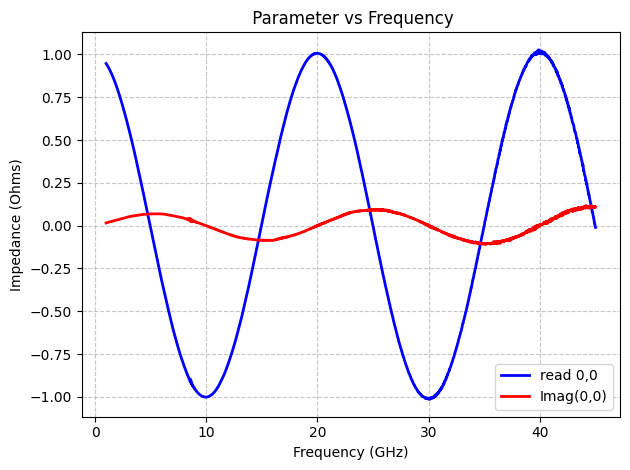

array([1.00000e+09, 1.02750e+09, 1.05500e+09, ..., 4.49450e+10,
       4.49725e+10, 4.50000e+10], shape=(1601,))

In [ ]:

# 1. Load the .s2p file 
thru = rf.Network('GEECI_meas_18min_21_may_2026/SUB3/SETA/thru1.s2p')

length_A3_thru_1 = (6500 - (128.8+139.4)) * 1e-6  # Convert micrometers to meters
plot_abcd(thru.a,0,0)



In [ ]:
thru = rf.Network('GEECI_meas_18min_21_may_2026/SUB3/SETA/thru1.s2p')
covered_thru = rf.Network(r'GEECI_meas_18min_21_may_2026\DMD\SETA\tn2.s2p')
FCB = rf.Network(r'GEECI_meas_18min_21_may_2026\SUB2\SetA\30um\TN6_15um.s2p')
T_FCB = FCB.a
thru_len = (6500 - (128.8+139.4)) * 1e-6  # Convert micrometers to meters
thru_len

0.0062318

In [ ]:
# deembeddedin the covered thru
T_thru_442 = scale_transmission_line_curve_fit(thru.a, thru_len, 442e-6)
T_thru_427 = scale_transmission_line_curve_fit(thru.a, thru_len, 427e-6)

T_cov_5311 = deembed_arrays(covered_thru.a,T_thru_442,T_thru_427)

T_cov_thru_430 = scale_transmission_line_curve_fit(T_cov_5311, 5311e-6, 430e-6)
T_cov_thru_400 = scale_transmission_line_curve_fit(T_cov_5311, 5311e-6, 400e-6)

In [ ]:
T_thru_434 = scale_transmission_line_curve_fit(thru.a, thru_len, 434e-6)
T_thru_465 = scale_transmission_line_curve_fit(thru.a, thru_len, 465e-6)

In [ ]:
T_FCB_de_once = deembed_arrays(T_FCB, T_thru_434, T_thru_465)

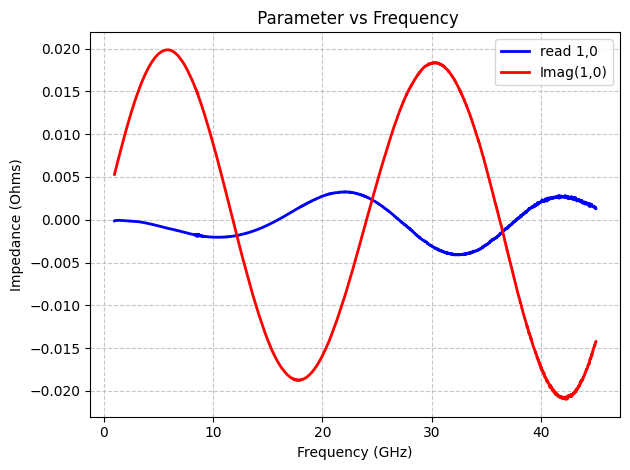

In [ ]:
T_FCB_de_twice = deembed_arrays(T_FCB_de_once, T_cov_thru_430, T_cov_thru_400)
plot_abcd(T_FCB_de_twice,0,0)

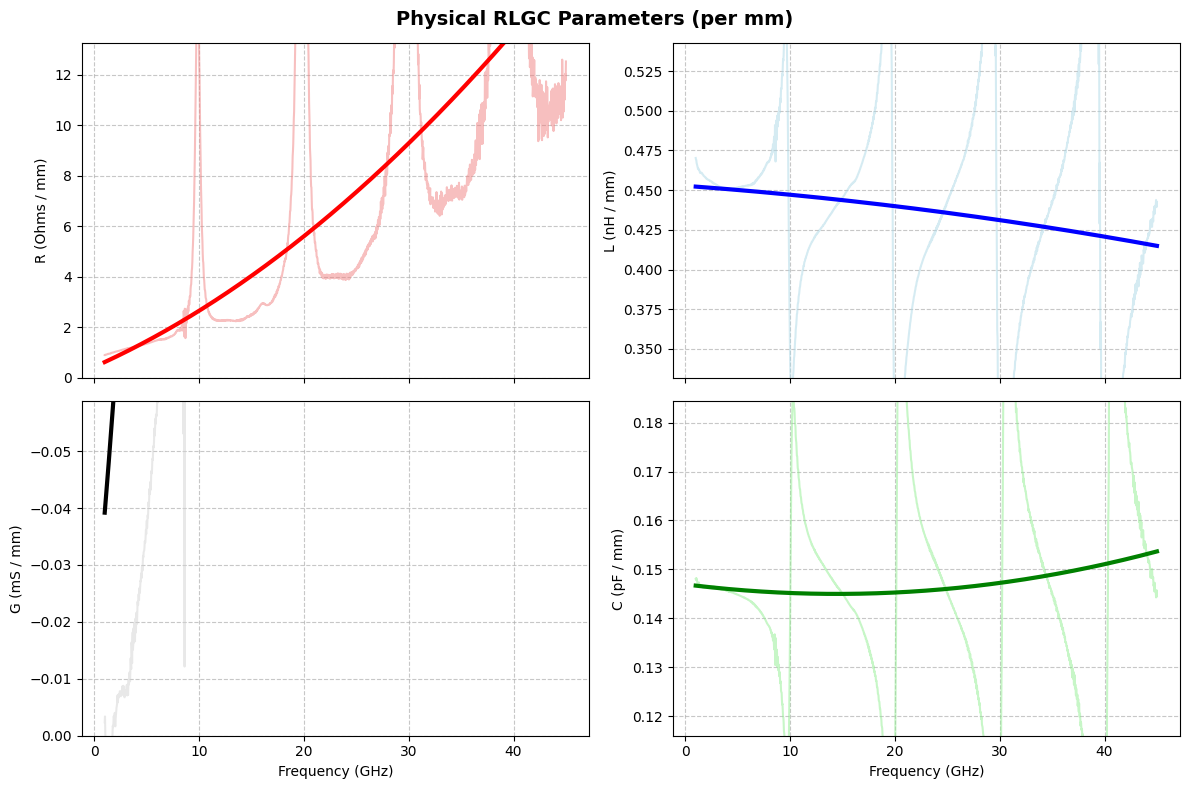

(array([  615.18884953,   620.49526167,   625.80720445, ...,
        16151.96909965, 16166.11350009, 16180.26343118], shape=(1601,)),
 array([4.52227141e-07, 4.52213509e-07, 4.52199865e-07, ...,
        4.14982779e-07, 4.14949785e-07, 4.14916779e-07], shape=(1601,)),
 array([-0.03919946, -0.03981665, -0.04043644, ..., -4.3455241 ,
        -4.35029916, -4.35507682], shape=(1601,)),
 array([1.46678725e-10, 1.46671813e-10, 1.46664915e-10, ...,
        1.53638961e-10, 1.53654598e-10, 1.53670249e-10], shape=(1601,)))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def extract_smooth_RLGC(T_array, length_meters, freq_hz):
    """
    Extracts distributed R, L, G, C parameters and applies adaptive 
    curve-fitting to remove half-wavelength resonance singularities.
    """
    omega = 2.0 * np.pi * freq_hz + 1e-15
    
    A = T_array[:, 0, 0]
    B = T_array[:, 0, 1]
    C = T_array[:, 1, 0]
    
    # ---------------------------------------------------------
    # 1. Raw Extraction
    # ---------------------------------------------------------
    Z0 = np.sqrt(B / C)
    root_term = np.sqrt(A**2 - 1.0 + 0j)
    root1 = A + root_term
    root2 = A - root_term
    exp_minus_gl = np.where(np.abs(root1) < 1.0, root1, root2)
    
    alpha_l = -np.log(np.abs(exp_minus_gl))
    beta_l = -np.unwrap(np.angle(exp_minus_gl))
    gamma = (alpha_l + 1j * beta_l) / length_meters
    
    Z_dist = gamma * Z0
    Y_dist = gamma / Z0
    
    R_raw = np.real(Z_dist)
    L_raw = np.imag(Z_dist) / omega
    G_raw = np.real(Y_dist)
    C_raw = np.imag(Y_dist) / omega
    
    # ---------------------------------------------------------
    # 2. Adaptive Masking & Curve Fitting
    # ---------------------------------------------------------
    # Inductance is the most stable parameter. We use its 10th and 90th 
    # percentiles to identify the clean baseline and throw away the spikes.
    L_lower, L_upper = np.percentile(L_raw, [10, 90])
    valid_mask = (L_raw > L_lower) & (L_raw < L_upper)
    
    freq_GHz = freq_hz / 1e9
    x_valid = freq_GHz[valid_mask]
    
    # Fit smooth physical polynomials to the clean data
    pR = np.polyfit(x_valid, R_raw[valid_mask], 2)
    pL = np.polyfit(x_valid, L_raw[valid_mask], 2)
    pG = np.polyfit(x_valid, G_raw[valid_mask], 2)
    pC = np.polyfit(x_valid, C_raw[valid_mask], 2)
    
    R_clean = np.polyval(pR, freq_GHz)
    L_clean = np.polyval(pL, freq_GHz)
    G_clean = np.polyval(pG, freq_GHz)
    C_clean = np.polyval(pC, freq_GHz)
    
    # ---------------------------------------------------------
    # 3. Plotting the Clean Data vs Raw Data
    # ---------------------------------------------------------
    fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    fig.suptitle('Physical RLGC Parameters (per mm)', fontsize=14, fontweight='bold')
    
    # Resistance
    axs[0, 0].plot(freq_GHz, R_raw * 1e-3, color='lightcoral', alpha=0.5)
    axs[0, 0].plot(freq_GHz, R_clean * 1e-3, 'r', linewidth=3)
    axs[0, 0].set_ylabel('R (Ohms / mm)')
    axs[0, 0].grid(True, linestyle='--', alpha=0.7)
    axs[0, 0].set_ylim(0, np.median(R_clean * 1e-3) * 2)
    
    # Inductance
    axs[0, 1].plot(freq_GHz, L_raw * 1e9 * 1e-3, color='lightblue', alpha=0.5)
    axs[0, 1].plot(freq_GHz, L_clean * 1e9 * 1e-3, 'b', linewidth=3)
    axs[0, 1].set_ylabel('L (nH / mm)')
    axs[0, 1].grid(True, linestyle='--', alpha=0.7)
    axs[0, 1].set_ylim(np.min(L_clean * 1e9 * 1e-3) * 0.8, np.max(L_clean * 1e9 * 1e-3) * 1.2)
    
    # Conductance
    axs[1, 0].plot(freq_GHz, G_raw * 1e3 * 1e-3, color='lightgray', alpha=0.5)
    axs[1, 0].plot(freq_GHz, G_clean * 1e3 * 1e-3, 'k', linewidth=3)
    axs[1, 0].set_ylabel('G (mS / mm)')
    axs[1, 0].set_xlabel('Frequency (GHz)')
    axs[1, 0].grid(True, linestyle='--', alpha=0.7)
    axs[1, 0].set_ylim(0, np.max(G_clean * 1e3 * 1e-3) * 1.5)
    
    # Capacitance
    axs[1, 1].plot(freq_GHz, C_raw * 1e12 * 1e-3, color='lightgreen', alpha=0.5)
    axs[1, 1].plot(freq_GHz, C_clean * 1e12 * 1e-3, 'g', linewidth=3)
    axs[1, 1].set_ylabel('C (pF / mm)')
    axs[1, 1].set_xlabel('Frequency (GHz)')
    axs[1, 1].grid(True, linestyle='--', alpha=0.7)
    axs[1, 1].set_ylim(np.min(C_clean * 1e12 * 1e-3) * 0.8, np.max(C_clean * 1e12 * 1e-3) * 1.2)
    
    plt.tight_layout()
    plt.show()

    return R_clean, L_clean, G_clean, C_clean

extract_smooth_RLGC(thru.a,thru_len,thru.f)

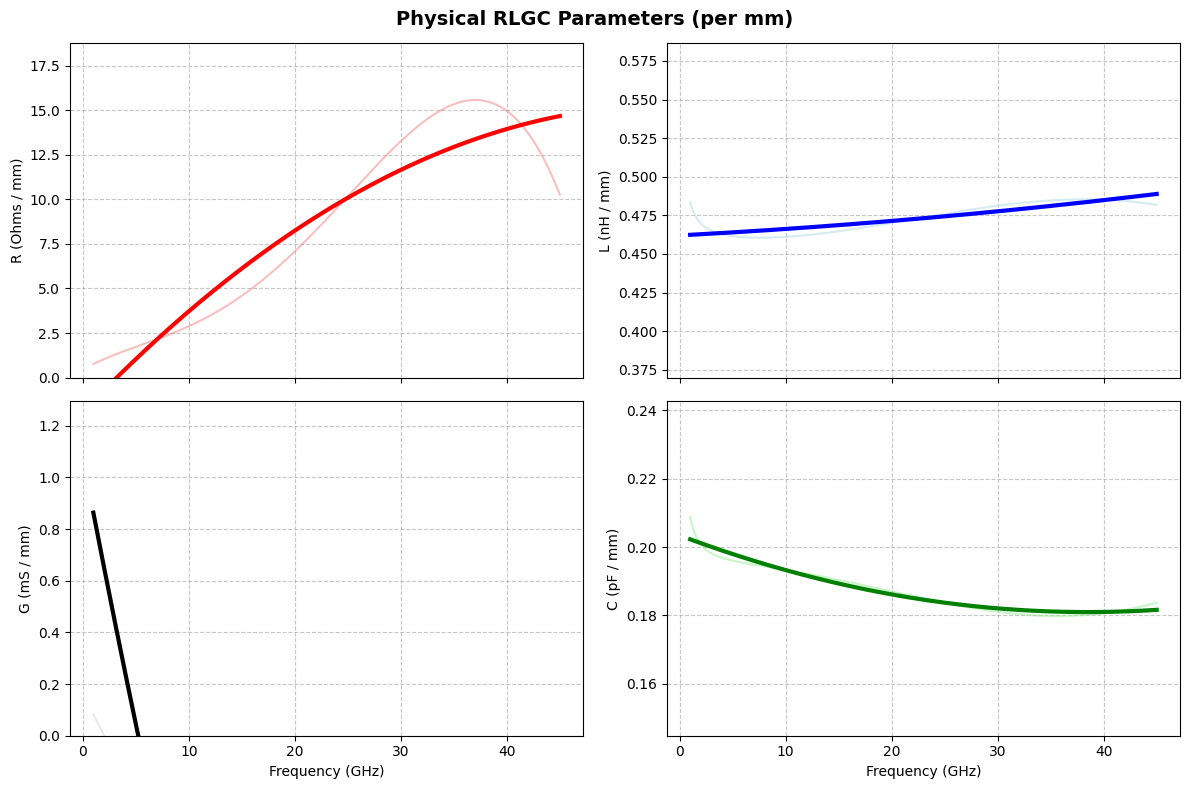

(array([-1310.40404982, -1293.65623529, -1276.91687075, ...,
        14670.37306395, 14673.61777202, 14676.85403008], shape=(1601,)),
 array([4.62369186e-07, 4.62379536e-07, 4.62389893e-07, ...,
        4.88786147e-07, 4.88808867e-07, 4.88831596e-07], shape=(1601,)),
 array([ 0.86347594,  0.85763506,  0.85179725, ..., -4.55093328,
        -4.55186581, -4.55279527], shape=(1601,)),
 array([2.02273677e-10, 2.02242416e-10, 2.02211177e-10, ...,
        1.81613049e-10, 1.81618476e-10, 1.81623925e-10], shape=(1601,)))

In [ ]:
extract_smooth_RLGC(T_cov_thru_400,400e-6,thru.f)


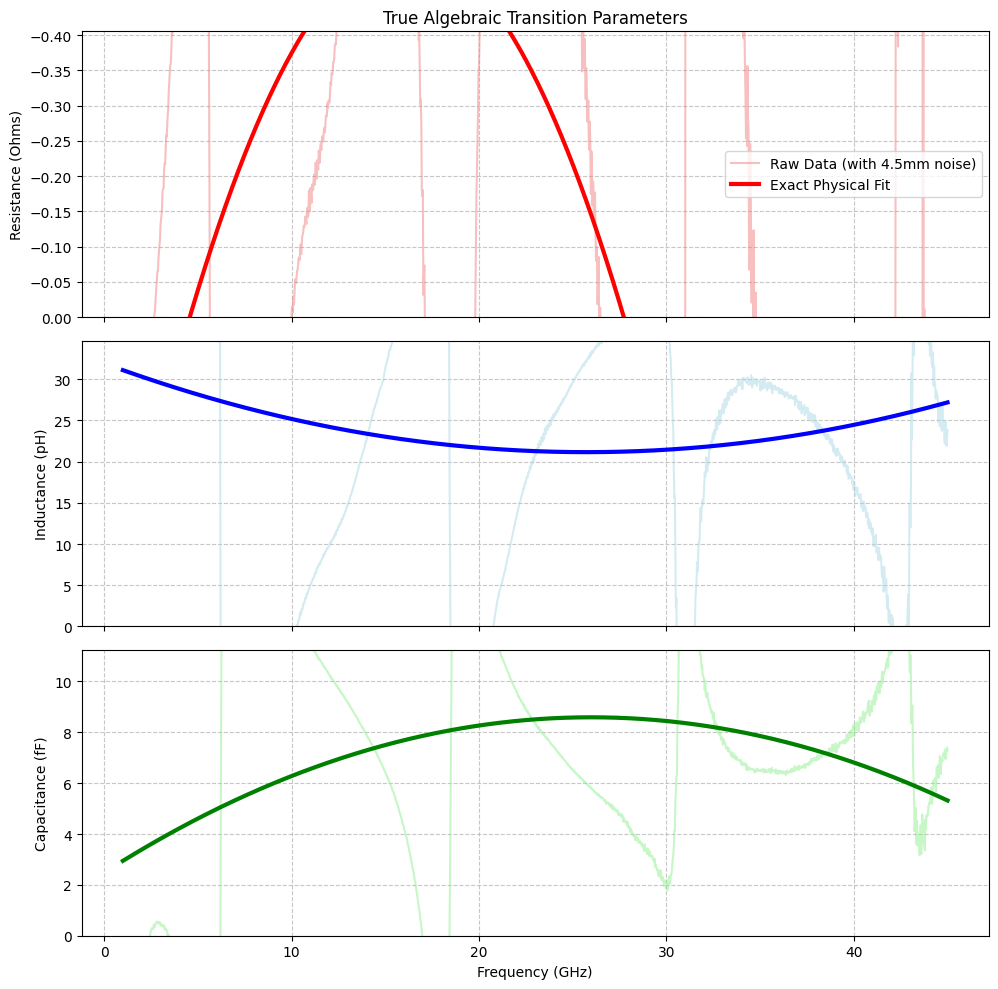

In [ ]:
T_cov_thru_4440 = scale_transmission_line_curve_fit(T_cov_5311, 5311e-6, 4250e-6)
R_ext, L_ext, C_ext = extract_RLC_exact_cascade(T_FCB_de_twice, T_cov_thru_4440, thru.f)

<>:42: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:42: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\hrith\AppData\Local\Temp\ipykernel_9636\3765915178.py:42: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  label=f'{L_test*1e6:.0f} $\mu$m')


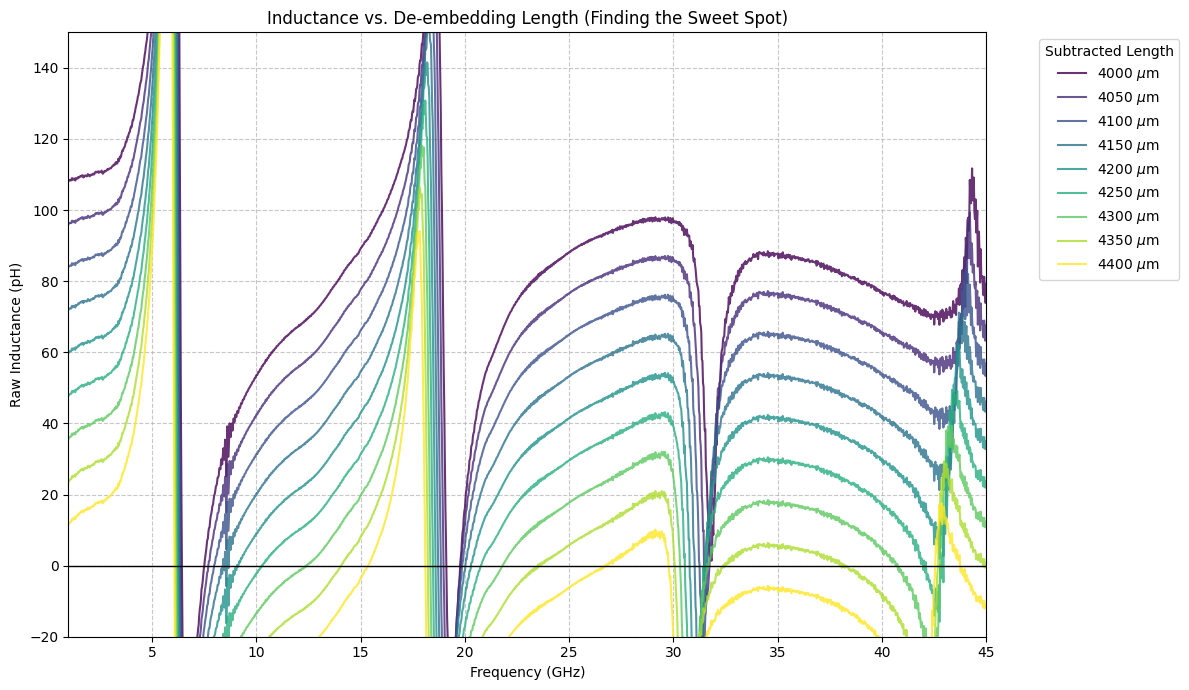

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def sweep_deembed_length(T_inner_measured, T_cov_thru, orig_len, test_lengths, freq_hz):
    """
    Sweeps a list of test lengths to visually calibrate the optimum de-embedding reference plane.
    """
    plt.figure(figsize=(12, 7))
    
    # Generate a nice color gradient for the sweep
    colors = cm.viridis(np.linspace(0, 1, len(test_lengths)))
    omega = 2.0 * np.pi * freq_hz + 1e-15
    freq_GHz = freq_hz / 1e9
    
    # Extract measured matrices once
    Am = T_inner_measured[:, 0, 0]
    Bm = T_inner_measured[:, 0, 1]
    Cm = T_inner_measured[:, 1, 0]

    for i, L_test in enumerate(test_lengths):
        # 1. Scale the thru to the current test length
        T_scaled = scale_transmission_line_curve_fit(T_cov_thru, orig_len, L_test)
        
        Ac = T_scaled[:, 0, 0]
        Bc = T_scaled[:, 0, 1]
        Cc = T_scaled[:, 1, 0]
        
        # 2. Exact Algebraic Extraction (B_t parameter)
        num = (Am + Ac)**2
        den = (Am + Ac)**2 - (Bm - Bc) * (Cm - Cc)
        A_t = np.sqrt(num / den)
        A_t = np.where(np.real(A_t) < 0, -A_t, A_t) # Positive real root
        
        B_t = A_t * (Bm - Bc) / (Am + Ac)
        
        # 3. Extract raw Inductance
        L_raw = np.imag(B_t) / omega
        
        # Plot the raw data
        plt.plot(freq_GHz, L_raw * 1e12, color=colors[i], linewidth=1.5, alpha=0.8, 
                 label=f'{L_test*1e6:.0f} $\mu$m')

    # Formatting the Plot
    plt.axhline(0, color='black', linewidth=1) # Zero-line reference
    
    # We restrict the Y-axis severely to clip the massive spikes and focus on the baseline
    plt.ylim(-20, 150) 
    plt.xlim(freq_GHz[0], freq_GHz[-1])
    
    plt.title('Inductance vs. De-embedding Length (Finding the Sweet Spot)')
    plt.ylabel('Raw Inductance (pH)')
    plt.xlabel('Frequency (GHz)')
    plt.legend(title='Subtracted Length', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# ==========================================
# How to run it:
# ==========================================
# Generate an array of 9 test lengths from 4000um to 4400um (50um steps)
lengths_to_test = np.linspace(4000e-6, 4400e-6, 9)

sweep_deembed_length(T_FCB_de_twice, T_cov_5311, 5311e-6, lengths_to_test, thru.f)